
# Gemfinder — Unreliability Matrix (ρ) Sensitivity Analysis

**Purpose:** test how small changes in a real test–retest unreliability matrix \( \rho \) change the existing Gemfinder neural-network outputs.

This notebook is designed around the project files:

- `Data.zip`
  - `RY25_PreMay10.csv`
  - `RY25_PostMay10.csv`
- `Unreliability Matrices.zip`
  - `unreliability-matrices.json`
- `final_network_July15_22.zip`
  - existing ONNX neural network
  - network metadata
  - feature-generation resources

### Important
The current project scope is focused on **four-option Likert items**.  
The unreliability JSON contains both 4×4 and 6×6 matrices, so this notebook automatically filters to 4×4 matrices.

The notebook does **not change the survey responses** when performing the sensitivity test. It keeps the group histograms fixed and perturbs only \( \rho \).



## Expected data format

### 1. Survey CSV — respondent-level data
One row = one survey respondent.

Example structure:

| school | grade | gender | ry2 | ry3 | ry9 | ph1 | ... |
|---|---:|---|---:|---:|---:|---:|---|
| school_A | 6 | M | 4 | 1 | 3 | 2 | ... |
| school_A | 7 | F | 3 | 2 | 4 | 1 | ... |

For a four-option item such as `ry9`, valid responses should be:

\[
1,\;2,\;3,\;4
\]

Missing responses can remain `NaN`; they are ignored when building the response histogram.

### 2. Unreliability-matrix JSON
Expected format:

```json
{
  "ry9": [
    [0.70, 0.20, 0.08, 0.02],
    [0.10, 0.60, 0.25, 0.05],
    [0.02, 0.15, 0.65, 0.18],
    [0.01, 0.03, 0.16, 0.80]
  ]
}
```

Each row must satisfy:

\[
\rho_{ji}\ge 0,
\qquad
\sum_i \rho_{ji}=1
\]

### 3. Optional compact comparison-case CSV
If you later want to bypass respondent-level data, a compact case can contain:

`case_id, item, group_variable, group_a, group_b, X1, X2, X3, X4, Y1, Y2, Y3, Y4, n_X, n_Y`

where `X1..X4` and `Y1..Y4` are response counts.


In [1]:

from pathlib import Path
import json
import zipfile
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# EDIT THESE PATHS IF REQUIRED
# -----------------------------
DATA_ZIP = Path("Data.zip")
RHO_ZIP = Path("Unreliability Matrices.zip")
NETWORK_ZIP = Path("final_network_July15_22.zip")

WORK_DIR = Path("gemfinder_work")
WORK_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Working directory:", WORK_DIR.resolve())


Working directory: /content/gemfinder_work


## 1. Extract the project archives

In [2]:

def extract_zip(zip_path, target_dir):
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    if not Path(zip_path).exists():
        print(f"Missing: {zip_path}")
        return False
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(target_dir)
    print(f"Extracted {zip_path} -> {target_dir}")
    return True

extract_zip(DATA_ZIP, WORK_DIR)
extract_zip(RHO_ZIP, WORK_DIR)
extract_zip(NETWORK_ZIP, WORK_DIR)


Missing: Data.zip
Missing: Unreliability Matrices.zip
Missing: final_network_July15_22.zip


False

## 2. Locate and load the real survey data and ρ matrices

In [3]:

def find_one(root, filename):
    matches = list(Path(root).rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under {root}")
    return matches[0]

# pre_path = find_one(WORK_DIR, "RY25_PreMay10.csv")
pre_path = "/content/RY25_PreMay10.csv"
post_path = find_one(WORK_DIR, "RY25_PostMay10.csv")
rho_path = find_one(WORK_DIR, "unreliability-matrices.json")

print("Pre-May CSV :", pre_path)
print("Post-May CSV:", post_path)
print("Rho JSON    :", rho_path)

# low_memory=False avoids mixed-type chunk warnings in large survey files
pre = pd.read_csv(pre_path, low_memory=False)
post = pd.read_csv(post_path, low_memory=False)

with open(rho_path, "r") as f:
    rho_dict = json.load(f)

print("\nPre-May shape :", pre.shape)
print("Post-May shape:", post.shape)
print("Number of rho matrices:", len(rho_dict))


FileNotFoundError: Could not find RY25_PreMay10.csv under gemfinder_work

In [4]:
def find_one(root, filename):
    matches = list(Path(root).rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under {root}")
    return matches[0]

# pre_path = find_one(WORK_DIR, "RY25_PreMay10.csv")
pre_path = "/content/RY25_PreMay10.csv"
post_path = "./RY25_PostMay10.csv"
rho_path = "./unreliability-matrices.json"

print("Pre-May CSV :", pre_path)
print("Post-May CSV:", post_path)
print("Rho JSON    :", rho_path)

# low_memory=False avoids mixed-type chunk warnings in large survey files
pre = pd.read_csv(pre_path, low_memory=False)
post = pd.read_csv(post_path, low_memory=False)

with open(rho_path, "r") as f:
    rho_dict = json.load(f)

print("\nPre-May shape :", pre.shape)
print("Post-May shape:", post.shape)
print("Number of rho matrices:", len(rho_dict))


Pre-May CSV : /content/RY25_PreMay10.csv
Post-May CSV: ./RY25_PostMay10.csv
Rho JSON    : ./unreliability-matrices.json

Pre-May shape : (114770, 81)
Post-May shape: (71063, 85)
Number of rho matrices: 59


## 3. Inspect matrix dimensions and keep the 4×4 Likert matrices

In [5]:

rho_shapes = {
    item: np.asarray(matrix, dtype=float).shape
    for item, matrix in rho_dict.items()
}

shape_counts = pd.Series(list(rho_shapes.values())).value_counts()
print(shape_counts)

rho_4x4 = {
    item: np.asarray(matrix, dtype=float)
    for item, matrix in rho_dict.items()
    if np.asarray(matrix).shape == (4, 4)
}

common_items = sorted(
    set(rho_4x4)
    & set(pre.columns)
    & set(post.columns)
)

print("\n4x4 rho matrices:", len(rho_4x4))
print("4-option items present in BOTH survey CSVs:", len(common_items))
print(common_items[:30])


(4, 4)    53
(6, 6)     6
Name: count, dtype: int64

4x4 rho matrices: 53
4-option items present in BOTH survey CSVs: 40
['cop1', 'cop2', 'cop3', 'cop4', 'for1', 'ph1', 'ph2', 'ph3', 'ph4', 'phq3', 'phq4', 'phq5', 'phq7', 'ry10', 'ry11', 'ry13', 'ry14', 'ry15', 'ry16', 'ry17', 'ry18', 'ry2', 'ry20', 'ry21', 'ry22', 'ry25', 'ry26', 'ry27', 'ry28', 'ry29']



## 4. Choose one real survey comparison

For the first test, use **one survey item and two groups**.

The example below compares **Grade 6 vs Grade 7** for `ry9` in the Pre-May data.

You can later change:

- `ITEM`
- `GROUP_COLUMN`
- `GROUP_A`
- `GROUP_B`
- `SURVEY_DF`


In [6]:

SURVEY_DF = pre
ITEM = "ry9"
GROUP_COLUMN = "grade"
GROUP_A = 6
GROUP_B = 7

assert ITEM in SURVEY_DF.columns, f"{ITEM} not in survey data"
assert ITEM in rho_4x4, f"{ITEM} does not have a 4x4 rho matrix"

def response_counts(df, item, group_column, group_value, k=4):
    values = pd.to_numeric(
        df.loc[df[group_column] == group_value, item],
        errors="coerce"
    ).dropna()

    # Keep only the expected Likert categories
    values = values[values.isin(range(1, k + 1))].astype(int)

    counts = (
        values.value_counts()
        .reindex(range(1, k + 1), fill_value=0)
        .sort_index()
        .to_numpy(dtype=int)
    )
    return counts

X_counts = response_counts(SURVEY_DF, ITEM, GROUP_COLUMN, GROUP_A)
Y_counts = response_counts(SURVEY_DF, ITEM, GROUP_COLUMN, GROUP_B)

n_X = int(X_counts.sum())
n_Y = int(Y_counts.sum())

print(f"Item: {ITEM}")
print(f"{GROUP_COLUMN}={GROUP_A}: X =", X_counts, "n_X =", n_X)
print(f"{GROUP_COLUMN}={GROUP_B}: Y =", Y_counts, "n_Y =", n_Y)

print("\nNormalised X:", np.round(X_counts / n_X, 4))
print("Normalised Y:", np.round(Y_counts / n_Y, 4))


Item: ry9
grade=6: X = [ 430 1799 4888 8986] n_X = 16103
grade=7: Y = [ 368 1667 4754 7935] n_Y = 14724

Normalised X: [0.0267 0.1117 0.3035 0.558 ]
Normalised Y: [0.025  0.1132 0.3229 0.5389]


## 5. Validate and describe the original ρ matrix

In [7]:

rho = rho_4x4[ITEM].copy()

def validate_rho(rho, atol=1e-8):
    rho = np.asarray(rho, dtype=float)
    return {
        "shape": rho.shape,
        "all_nonnegative": bool(np.all(rho >= -atol)),
        "all_le_one": bool(np.all(rho <= 1 + atol)),
        "rows_sum_to_one": bool(np.allclose(rho.sum(axis=1), 1.0, atol=atol)),
        "row_sums": rho.sum(axis=1)
    }

def rho_metrics(rho):
    rho = np.asarray(rho, dtype=float)
    k = rho.shape[0]

    diagonal_certainty = np.mean(np.diag(rho))

    # Mean absolute directional asymmetry
    asymmetry = np.mean([
        abs(rho[i, j] - rho[j, i])
        for i in range(k)
        for j in range(i + 1, k)
    ])

    # Mean row entropy
    safe = np.clip(rho, 1e-12, 1.0)
    row_entropy = -np.sum(safe * np.log(safe), axis=1)

    return {
        "diag_certainty": diagonal_certainty,
        "asymmetry": asymmetry,
        "mean_row_entropy": np.mean(row_entropy)
    }

print("rho =")
display(pd.DataFrame(rho))

print("\nValidation:")
print(validate_rho(rho))

print("\nMatrix descriptors:")
print(rho_metrics(rho))


rho =


,0,1,2,3
0,0.43,0.41,0.10,0.06
1,0.05,0.57,0.28,0.10
2,0.01,0.12,0.61,0.27
3,0.01,0.02,0.16,0.81



Validation:
{'shape': (4, 4), 'all_nonnegative': True, 'all_le_one': True, 'rows_sum_to_one': False, 'row_sums': array([1.  , 1.  , 1.01, 1.  ])}

Matrix descriptors:
{'diag_certainty': np.float64(0.605), 'asymmetry': np.float64(0.14166666666666666), 'mean_row_entropy': np.float64(0.9320305293576531)}



## 6. Perturb ρ while preserving probability constraints

We generate:

\[
\rho' = \rho + \Delta
\]

Then we:

1. clip negative values to 0;
2. renormalise every row.

The survey groups \(X,Y\) remain unchanged. Only \( \rho \) is changed.


In [8]:

def perturb_rho(rho, sigma, rng):
    rho = np.asarray(rho, dtype=float)
    noise = rng.normal(0.0, sigma, size=rho.shape)

    perturbed = rho + noise
    perturbed = np.clip(perturbed, 0.0, None)

    row_sums = perturbed.sum(axis=1, keepdims=True)

    # Very unlikely, but protect against a row becoming all zeros
    bad_rows = np.where(row_sums[:, 0] == 0)[0]
    for r in bad_rows:
        perturbed[r] = rho[r]

    perturbed = perturbed / perturbed.sum(axis=1, keepdims=True)
    return perturbed

rho_test = perturb_rho(rho, sigma=0.005, rng=rng)

print("Original:")
display(pd.DataFrame(rho))
print("Perturbed:")
display(pd.DataFrame(rho_test))
print(validate_rho(rho_test))


Original:


,0,1,2,3
0,0.43,0.41,0.10,0.06
1,0.05,0.57,0.28,0.10
2,0.01,0.12,0.61,0.27
3,0.01,0.02,0.16,0.81


Perturbed:


,0,1,2,3
0,0.429471,0.402875,0.103259,0.064395
1,0.040949,0.573355,0.285553,0.100142
2,0.009780,0.114144,0.605952,0.270124
3,0.010289,0.025534,0.161690,0.802488


{'shape': (4, 4), 'all_nonnegative': True, 'all_le_one': True, 'rows_sum_to_one': True, 'row_sums': array([1., 1., 1., 1.])}



## 7. Existing Gemfinder neural-network adapter

The supplied network predicts the two Gamma parameters:

\[
(\alpha,\beta)
\]

where the project metadata calls them:

- `shape` = \( \alpha \)
- `rate` = \( \beta \)

The following code reproduces the feature calculation used by the supplied Gemfinder portal script.

> If `onnxruntime` is not installed, run:
>
> `pip install onnxruntime`


In [9]:

def moment_calculator(prob_dist):
    prob_dist = np.asarray(prob_dist, dtype=float)
    rv = np.arange(1, len(prob_dist) + 1)

    mean = np.dot(rv, prob_dist)
    variance = np.dot((rv - mean) ** 2, prob_dist)
    stdev = np.sqrt(max(variance, 1e-12))

    skewness = np.dot((rv - mean) ** 3, prob_dist) / stdev ** 3
    kurtosis = np.dot((rv - mean) ** 4, prob_dist) / stdev ** 4

    return mean, stdev, skewness, kurtosis

def original_asymm_calc(P):
    # Matches the supplied feature_calculation_portal_script.py
    pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
    return np.mean([(P[i,j] - P[j,i])**2 for i,j in pairs])

def extract_network_features(x_counts, y_counts, P):
    x_counts = np.asarray(x_counts, dtype=float)
    y_counts = np.asarray(y_counts, dtype=float)
    P = np.asarray(P, dtype=float)

    n_X = x_counts.sum()
    n_Y = y_counts.sum()

    X = x_counts / n_X
    Y = y_counts / n_Y
    XmY = np.abs(X - Y)

    mean_X, stdev_X, skew_X, kurt_X = moment_calculator(X)
    mean_Y, stdev_Y, skew_Y, kurt_Y = moment_calculator(Y)

    euclid = np.round(np.sqrt(np.sum((X - Y) ** 2)), 4)

    features = {}

    for i in range(4):
        features[f"X_{i+1}"] = X[i]
    for i in range(4):
        features[f"Y_{i+1}"] = Y[i]
    for i in range(4):
        features[f"XmY_{i+1}"] = XmY[i]

    features.update({
        "mean_X": mean_X,
        "stdev_X": stdev_X,
        "skewness_X": skew_X,
        "kurtosis_X": kurt_X,
        "mean_Y": mean_Y,
        "stdev_Y": stdev_Y,
        "skewness_Y": skew_Y,
        "kurtosis_Y": kurt_Y,
        "euclid_dist_XY": euclid,
        "n_X": n_X,
        "n_Y": n_Y,
    })

    for i, value in enumerate(P.flatten()):
        features[f"P_{i}"] = value

    features["asymm"] = original_asymm_calc(P)

    return pd.Series(features)


In [11]:

# Locate supplied model + metadata
metadata_path = "EXP002.json"
onnx_path = "EXP002_nn_optimal_epoch.onnx"

with open(metadata_path, "r") as f:
    metadata = json.load(f)

mm_df = pd.read_json(io.StringIO(metadata["min_max_df"]))

print("Model:", onnx_path)
print("Feature count:", len(metadata["feature_labels"]))
print("Outputs:", metadata["output_labels"])
print("P transform:", metadata["P_transform"])


Model: EXP002_nn_optimal_epoch.onnx
Feature count: 40
Outputs: ['shape', 'rate']
P transform: all_P_asymm


In [18]:
def minmax_normalise(value, minimum, maximum):
    if maximum == minimum:
        return 0.0
    return (value - minimum) / (maximum - minimum)


def reverse_minmax(value, minimum, maximum):
    return (maximum - minimum) * value + minimum


def prepare_model_input(features, metadata, mm_df):
    values = []

    for label in metadata["feature_labels"]:
        value = float(features[label])

        row = mm_df.loc[mm_df["column"] == label]

        if row.empty:
            raise KeyError(
                f"Missing min/max information for feature: {label}"
            )

        fmin = float(row["min"].iloc[0])
        fmax = float(row["max"].iloc[0])

        values.append(
            minmax_normalise(value, fmin, fmax)
        )

    # IMPORTANT:
    # ONNX model expects rank 1, not shape (1, n_features)
    return np.asarray(values, dtype=np.float32)


def reverse_output(name, normalised_value, mm_df):
    row = mm_df.loc[mm_df["column"] == name]

    if row.empty:
        raise KeyError(
            f"Missing min/max information for output: {name}"
        )

    fmin = float(row["min"].iloc[0])
    fmax = float(row["max"].iloc[0])

    return reverse_minmax(
        float(normalised_value),
        fmin,
        fmax
    )

In [16]:
!pip install onnxruntime

In [19]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession(
    str(onnx_path),
    providers=["CPUExecutionProvider"]
)

print("ONNX input information:")
for inp in session.get_inputs():
    print(
        "name =", inp.name,
        "| shape =", inp.shape,
        "| type =", inp.type
    )

print("\nONNX output information:")
for out in session.get_outputs():
    print(
        "name =", out.name,
        "| shape =", out.shape,
        "| type =", out.type
    )


def predict_gamma(x_counts, y_counts, rho_matrix):

    features = extract_network_features(
        x_counts,
        y_counts,
        rho_matrix
    )

    model_input = prepare_model_input(
        features,
        metadata,
        mm_df
    )

    input_name = session.get_inputs()[0].name

    print("Model input shape:", model_input.shape)

    raw_outputs = session.run(
        None,
        {
            input_name: model_input
        }
    )

    print(
        "Raw output shapes:",
        [np.asarray(o).shape for o in raw_outputs]
    )

    # Flatten all ONNX outputs safely
    flat = np.concatenate(
        [
            np.asarray(output).reshape(-1)
            for output in raw_outputs
        ]
    )

    if len(flat) < 2:
        raise ValueError(
            f"Expected at least shape and rate outputs, "
            f"but received: {raw_outputs}"
        )

    alpha = reverse_output(
        "shape",
        flat[0],
        mm_df
    )

    beta = reverse_output(
        "rate",
        flat[1],
        mm_df
    )

    return {
        "alpha": alpha,
        "beta": beta,
        "raw_shape": float(flat[0]),
        "raw_rate": float(flat[1])
    }

ONNX input information:
name = input.1 | shape = [40] | type = tensor(float)

ONNX output information:
name = 125 | shape = [2] | type = tensor(float)


In [20]:
baseline_prediction = predict_gamma(
    X_counts,
    Y_counts,
    rho
)

print("\nBaseline Gamma prediction")
print("-------------------------")
print("Alpha / shape:", baseline_prediction["alpha"])
print("Beta / rate:", baseline_prediction["beta"])

Model input shape: (40,)
Raw output shapes: [(2,)]

Baseline Gamma prediction
-------------------------
Alpha / shape: 48.90138317858819
Beta / rate: 2145.569230894742


In [21]:
from pathlib import Path

BASE_DIR = Path("/content")

PRE_PATH = BASE_DIR / "RY25_PreMay10.csv"
POST_PATH = BASE_DIR / "RY25_PostMay10.csv"

RHO_PATH = BASE_DIR / "unreliability-matrices.json"

METADATA_PATH = BASE_DIR / "EXP002.json"

ONNX_PATH = BASE_DIR / "EXP002_nn_optimal_epoch.onnx"

In [22]:
print("Files check")
print("-----------")

for path in [
    PRE_PATH,
    POST_PATH,
    RHO_PATH,
    METADATA_PATH,
    ONNX_PATH
]:
    print(path.name, "->", path.exists())

Files check
-----------
RY25_PreMay10.csv -> True
RY25_PostMay10.csv -> True
unreliability-matrices.json -> True
EXP002.json -> True
EXP002_nn_optimal_epoch.onnx -> True



## 8. Run the ρ-sensitivity experiment

Start small. Recommended initial configuration:

- 4 perturbation sizes
- 100 repetitions each
- one survey item
- one group comparison

After confirming the code works, increase repetitions and run across more survey items.


In [23]:

SIGMAS = [0.001, 0.005, 0.01, 0.02]
N_REPETITIONS = 100

if ONNX_AVAILABLE:
    baseline = predict_gamma(X_counts, Y_counts, rho)

    results = []

    for sigma in SIGMAS:
        for rep in range(N_REPETITIONS):
            rho_p = perturb_rho(rho, sigma=sigma, rng=rng)
            pred = predict_gamma(X_counts, Y_counts, rho_p)

            results.append({
                "item": ITEM,
                "group_column": GROUP_COLUMN,
                "group_A": GROUP_A,
                "group_B": GROUP_B,
                "n_X": n_X,
                "n_Y": n_Y,
                "sigma": sigma,
                "rep": rep,
                "rho_frobenius_change": np.linalg.norm(rho_p - rho),
                "alpha": pred["alpha"],
                "beta": pred["beta"],
                "delta_alpha": abs(pred["alpha"] - baseline["alpha"]),
                "delta_beta": abs(pred["beta"] - baseline["beta"]),
            })

    sensitivity_df = pd.DataFrame(results)
    display(sensitivity_df.head())

    output_csv = WORK_DIR / "rho_sensitivity_results.csv"
    sensitivity_df.to_csv(output_csv, index=False)
    print("Saved:", output_csv)
else:
    print("Install onnxruntime, then rerun this cell.")


Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw output shapes: [(2,)]
Model input shape: (40,)
Raw ou

,item,group_column,group_A,group_B,n_X,n_Y,sigma,rep,rho_frobenius_change,alpha,beta,delta_alpha,delta_beta
0,ry9,grade,6,7,16103,14724,0.001,0,0.007265,48.907246,2145.876904,0.005863,0.307673
1,ry9,grade,6,7,16103,14724,0.001,1,0.008077,48.891666,2147.465551,0.009717,1.896320
2,ry9,grade,6,7,16103,14724,0.001,2,0.008576,48.895099,2141.744278,0.006284,3.824953
3,ry9,grade,6,7,16103,14724,0.001,3,0.006956,48.892259,2141.446912,0.009125,4.122319
4,ry9,grade,6,7,16103,14724,0.001,4,0.007594,48.855657,2138.343160,0.045726,7.226071


Saved: gemfinder_work/rho_sensitivity_results.csv


## 9. Summarise and visualise sensitivity

,sigma,mean_delta_alpha,max_delta_alpha,mean_delta_beta,max_delta_beta,mean_rho_change
0,0.001,0.025289,0.084096,3.922762,14.829596,0.007671
1,0.005,0.120047,0.621887,16.000893,61.426272,0.020613
2,0.010,0.302985,1.736991,35.768604,129.084561,0.038724
3,0.020,0.701177,2.655897,66.938717,237.735808,0.075641


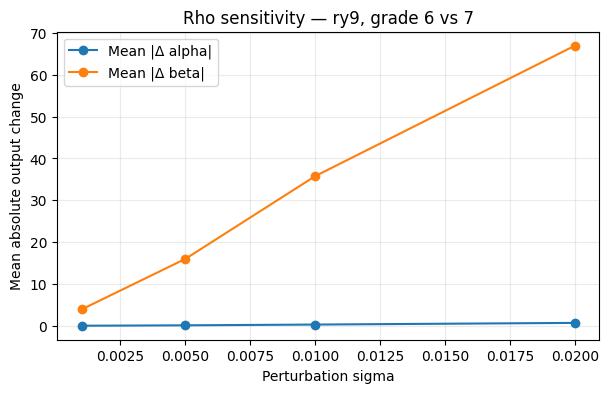

In [24]:

if ONNX_AVAILABLE:
    summary = (
        sensitivity_df
        .groupby("sigma")
        .agg(
            mean_delta_alpha=("delta_alpha", "mean"),
            max_delta_alpha=("delta_alpha", "max"),
            mean_delta_beta=("delta_beta", "mean"),
            max_delta_beta=("delta_beta", "max"),
            mean_rho_change=("rho_frobenius_change", "mean")
        )
        .reset_index()
    )
    display(summary)

    plt.figure(figsize=(7, 4))
    plt.plot(summary["sigma"], summary["mean_delta_alpha"], marker="o", label="Mean |Δ alpha|")
    plt.plot(summary["sigma"], summary["mean_delta_beta"], marker="o", label="Mean |Δ beta|")
    plt.xlabel("Perturbation sigma")
    plt.ylabel("Mean absolute output change")
    plt.title(f"Rho sensitivity — {ITEM}, {GROUP_COLUMN} {GROUP_A} vs {GROUP_B}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


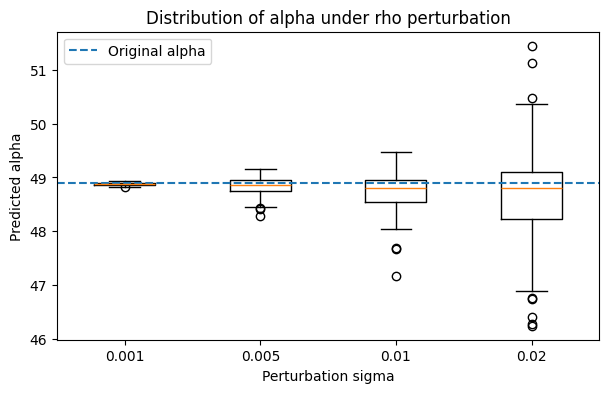

In [25]:

if ONNX_AVAILABLE:
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped = [
        sensitivity_df.loc[sensitivity_df["sigma"] == s, "alpha"].values
        for s in SIGMAS
    ]
    ax.boxplot(grouped, labels=[str(s) for s in SIGMAS])
    ax.axhline(baseline["alpha"], linestyle="--", label="Original alpha")
    ax.set_xlabel("Perturbation sigma")
    ax.set_ylabel("Predicted alpha")
    ax.set_title("Distribution of alpha under rho perturbation")
    ax.legend()
    plt.show()


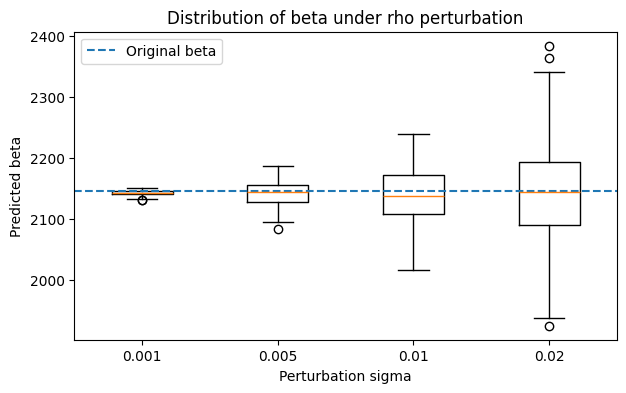

In [26]:

if ONNX_AVAILABLE:
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped = [
        sensitivity_df.loc[sensitivity_df["sigma"] == s, "beta"].values
        for s in SIGMAS
    ]
    ax.boxplot(grouped, labels=[str(s) for s in SIGMAS])
    ax.axhline(baseline["beta"], linestyle="--", label="Original beta")
    ax.set_xlabel("Perturbation sigma")
    ax.set_ylabel("Predicted beta")
    ax.set_title("Distribution of beta under rho perturbation")
    ax.legend()
    plt.show()



## 10. Optional next step — empirical uncertainty intervals

The repeated predictions can already be converted into uncertainty ranges.

For example, a 95% empirical interval for \( \alpha \) is:

\[
[Q_{0.025}(\alpha),\;Q_{0.975}(\alpha)]
\]

This is useful for the next project milestone: **confidence/posterior ranges on the model's two outputs**.


In [27]:

if ONNX_AVAILABLE:
    intervals = (
        sensitivity_df
        .groupby("sigma")
        .agg(
            alpha_low=("alpha", lambda x: np.quantile(x, 0.025)),
            alpha_median=("alpha", "median"),
            alpha_high=("alpha", lambda x: np.quantile(x, 0.975)),
            beta_low=("beta", lambda x: np.quantile(x, 0.025)),
            beta_median=("beta", "median"),
            beta_high=("beta", lambda x: np.quantile(x, 0.975)),
        )
        .reset_index()
    )

    display(intervals)


,sigma,alpha_low,alpha_median,alpha_high,beta_low,beta_median,beta_high
0,0.001,48.833421,48.880935,48.918383,2133.001318,2142.469657,2148.451661
1,0.005,48.446681,48.855799,49.100336,2099.457025,2143.545886,2178.942458
2,0.010,47.852856,48.806990,49.365661,2062.207360,2137.576275,2221.412992
3,0.020,46.571836,48.811836,50.416153,1955.618881,2143.856136,2328.189285
